Silas Bates

CS6180

HW4

2/27/26

In [13]:
!pip install python-dotenv huggingface-hub llama-index transformers sentence-transformers llama-index-llms-huggingface llama-index-embeddings-huggingface pdfplumber llama-index-llms-openrouter llama-index-retrievers-bm25 tabula-py  jpype1 pystemmer
!apt-get update
!apt-get install -y poppler-utils tesseract-ocr
!pip install pdf2image pytesseract

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
poppler-utils is already the ne

## 1. Setup & Configuration
In this section, we set up the necessary dependencies, including third-party libraries and API keys.
We also configure the language models (LLMs) and embedding models used throughout the tutorial.

Key Steps:
- Import required Python libraries.
- Load API keys securely from environment variables.
- Initialize the OpenRouter LLMs for both querying and evaluation.
- Set up the HuggingFace embedding model for text representation.
- Apply `nest_asyncio` to handle event loop issues in Jupyter environments.


In [78]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # Suppresses TensorFlow warnings
from dotenv import load_dotenv
import Stemmer
import nest_asyncio
import tabula
import pandas as pd
from dotenv import load_dotenv
from llama_index.core import Document
from llama_index.core import (SimpleDirectoryReader, VectorStoreIndex, Settings)
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from llama_index.llms.openrouter import OpenRouter
from llama_index.core.indices.query.query_transform import HyDEQueryTransform
from llama_index.core.query_engine import TransformQueryEngine
from llama_index.core.schema import QueryBundle
import asyncio
from pdf2image import convert_from_path
import pytesseract


load_dotenv(dotenv_path="./env")  # Load environment variables from .env file
# ✅ Load API Key Securely (No Hardcoding!)
api_key = os.getenv("OPENROUTER_API_KEY")
if api_key:
    print("✅ API Key Loaded Successfully:", api_key[:5] + "..." + api_key[-5:])
else:
    print("⚠️ API Key is missing! Check your .env file.")


# ✅ Initialize OpenRouter LLM
llm = OpenRouter(api_key=api_key, model="meta-llama/llama-3.1-8b-instruct", max_tokens=512, context_window=4096)
Judge_llm = OpenRouter(api_key=api_key, model="qwen/qwen-turbo", max_tokens=512, context_window=4096)
Settings.llm = llm

# ✅ Apply nest_asyncio to fix event loop issues in Jupyter
nest_asyncio.apply()

#✅ Set up embedding model
#embed_model_name = "sentence-transformers/all-MiniLM-L6-v2"
#embed_model = HuggingFaceEmbedding(model_name=embed_model_name)
#Settings.embed_model = embed_model

#New Medical Embedding model
embed_model_name = "NeuML/pubmedbert-base-embeddings"
embed_model = HuggingFaceEmbedding(model_name=embed_model_name)
Settings.embed_model = embed_model


✅ API Key Loaded Successfully: sk-or...970dd


## 2. Document Loading & Preprocessing
Here, we load the syllabus document from a PDF file and process it for retrieval.

Key Steps:
- Read the syllabus PDF and extract its textual content.
- Extract tabular data from the PDF using `tabula`.
- Convert the extracted table data into text format.
- Combine the extracted text and tables into a unified document.
- Define an ingestion pipeline to preprocess text by splitting it into manageable chunks and applying embeddings.


In [98]:
# ✅ Load Course Syllabus Document
pdf_path = "./WebMD.pdf"
images = convert_from_path(pdf_path)
image_text = ""
custom_config = r'--oem 3 --psm 11'
for i, image in enumerate(images):
    text = pytesseract.image_to_string(image, config=custom_config)
    image_text += f"\n--- Page {i+1} OCR Data ---\n" + text

ocr_document = Document(text=image_text)

documents = SimpleDirectoryReader(input_files=[pdf_path]).load_data()
documents.append(ocr_document)

# Convert table data into an additional Document
tables = tabula.read_pdf(pdf_path, pages="all")
table_docs = [df.to_markdown(index=False) for df in tables]
all_tables_text = "\n\n".join(table_docs)
document_from_tables = Document(text=all_tables_text)

# Combine original + table doc
documents = documents + [document_from_tables]

# ✅ Create the pipeline with transformations
from llama_index.core.node_parser import SentenceSplitter
from llama_index.core.ingestion import IngestionPipeline

pipeline = IngestionPipeline(transformations=[SentenceSplitter(chunk_size=256, chunk_overlap=20), embed_model])

# Run the pipeline
nodes = pipeline.run(documents=documents)


## 3. Indexing & Retrieval
Once the document is processed, we create multiple retrievers for efficient information retrieval.

Key Steps:
- Build a `VectorStoreIndex` from the preprocessed document chunks.
- Implement different retrieval methods:
  - **Base Retriever:** Retrieves the most relevant document chunk.
  - **AutoMerging Retriever:** Aggregates multiple related chunks before returning results.
  - **BM25 Retriever:** Uses term frequency-based ranking (a traditional information retrieval method).
  - **Hybrid Fusion Retriever:** (Task 4)
- Define retrieval hyperparameters, such as similarity threshold and number of top results to return.


In [99]:
# ✅ Create Vector Index and Query Engine
index = VectorStoreIndex(nodes)
query_engine = index.as_query_engine()

# ✅ Create base retrievers
base_retriever = index.as_retriever(similarity_top_k=1)
base_retriever_task_4 = index.as_retriever(similarity_top_k=5)

from llama_index.core.retrievers import AutoMergingRetriever
auto_base_retriever = index.as_retriever(similarity_top_k=3)
auto_merging_retriever = AutoMergingRetriever(auto_base_retriever, index.storage_context)

from llama_index.retrievers.bm25 import BM25Retriever
bm25_retriever = BM25Retriever.from_defaults(nodes=nodes, similarity_top_k=2, stemmer=Stemmer.Stemmer("english"), language="english")
bm25_retriever_task_4 = BM25Retriever.from_defaults(nodes=nodes, similarity_top_k=5, stemmer=Stemmer.Stemmer("english"), language="english")


# ❓ Create Hybrid Fusion Retriever (Task 4)
from llama_index.core.retrievers import QueryFusionRetriever
hybrid_retriever = QueryFusionRetriever([base_retriever_task_4, bm25_retriever_task_4],
                                        similarity_top_k=5, num_queries=1,
                                        mode="reciprocal_rerank", use_async=True)

# Hyde Retriever Wrapper for Evals
from llama_index.core.retrievers import BaseRetriever
class HyDERetriver (BaseRetriever):
    def __init__ (self, retriever, query_transform):
        self._retriever = retriever
        self._query_transform = query_transform
        super().__init__()

    def _retrieve(self, query_bundle: QueryBundle):
        hyde_query_bundle = self._query_transform(query_bundle) # Corrected: used _query_transform
        return self._retriever.retrieve(hyde_query_bundle)

HyDE_transform = HyDEQueryTransform(include_original=True)
HyDE_retriever = HyDERetriver(hybrid_retriever, HyDE_transform)


DEBUG:bm25s:Building index from IDs objects
DEBUG:bm25s:Building index from IDs objects


## 4. Query Engines & Evaluation Setup
In this section, we configure the query engines and set up evaluation metrics to assess retriever performance.

Key Steps:
- Instantiate query engines for each retrieval method to allow direct querying.
- Define evaluation models to measure:
  - **Faithfulness:** Whether the retrieved information is accurate and grounded in the original document.
  - **Relevancy:** Whether the retrieved information is relevant to the query.
- Configure different retriever evaluators to assess retrieval effectiveness using metrics such as:
  - Mean Reciprocal Rank (MRR)
  - Hit Rate
  - Precision
  - Recall


In [100]:
# ✅ Create query engines
from llama_index.core.query_engine import RetrieverQueryEngine

base_query_engine = RetrieverQueryEngine.from_args(base_retriever)
auto_query_engine = RetrieverQueryEngine.from_args(auto_merging_retriever)
bm25_query_engine = RetrieverQueryEngine.from_args(bm25_retriever)
hybrid_query_engine = RetrieverQueryEngine.from_args(hybrid_retriever)
hyde_query_engine = TransformQueryEngine(hybrid_query_engine, HyDE_transform)

# ✅ Initialize Evaluators
from llama_index.core.evaluation import FaithfulnessEvaluator, RelevancyEvaluator, RetrieverEvaluator

faithfulness_evaluator = FaithfulnessEvaluator(llm=Judge_llm)
relevancy_evaluator = RelevancyEvaluator(llm=Judge_llm)

# ✅ Define retriever evaluators
base_retriever_evaluator = RetrieverEvaluator.from_metric_names(["mrr", "hit_rate", "precision", "recall"], retriever=base_retriever)
auto_retriever_evaluator = RetrieverEvaluator.from_metric_names(["mrr", "hit_rate", "precision", "recall"], retriever=auto_merging_retriever)
bm25_retriever_evaluator = RetrieverEvaluator.from_metric_names(["mrr", "hit_rate", "precision", "recall"], retriever=bm25_retriever)
hybrid_retriever_evaluator = RetrieverEvaluator.from_metric_names(["mrr", "hit_rate", "precision","recall"], retriever=hybrid_retriever)
hyde_retriever_evaluator = RetrieverEvaluator.from_metric_names(["mrr", "hit_rate", "precision","recall"], retriever=HyDE_retriever)

## 5. Preparing Evaluation Questions & Display Functions

In this section, we define a set of evaluation questions to systematically assess the performance of different retrieval methods. Additionally, we create utility functions for displaying results in a structured and readable format.

Key Steps:
- Define a set of test queries (e.g., syllabus-related questions).
- Generate question-context pairs for automated evaluation.

To make evaluation results more interpretable, we define:
- **`displayify_df(df)`** – A helper function to format and display DataFrames neatly in Jupyter notebooks.
- **`display_retriever_eval_results(name, eval_results)`** – Computes and prints key retrieval evaluation metrics.

In [101]:
# ✅ Use Evaluation Questions
eval_questions = []
with open('eval_questions.txt', 'r') as file:
    for line in file:
        eval_questions.append(line.strip())

 #✅ Add more evaluation questions
#eval_questions = [
#    "Based on the diagram, what are the four distinct stages of a migraine attack?"
#]

from llama_index.core.evaluation import generate_question_context_pairs
qa_dataset = generate_question_context_pairs(nodes=nodes, llm=llm, num_questions_per_chunk=1)



# ✅ Pretty Display Function
def displayify_df(df):
    """For pretty displaying DataFrame in a notebook."""
    display_df = df.style.set_properties(
        **{
            "inline-size": "300px",
            "overflow-wrap": "break-word",
        }
    )
    display(display_df)

# Helper to display retrieval metrics
def display_retriever_eval_results(name, eval_results):
    """Build a small DataFrame summarizing retrieval metrics across queries."""
    print(f"=== {name} ===")
    metric_dicts = [res.metric_vals_dict for res in eval_results]
    if not metric_dicts:
        print("No retriever metrics found!")
        return
    df = pd.DataFrame(metric_dicts)
    #displayify_df(df)
    print("Mean:\n", df.mean(numeric_only=True), "\n")

# Helper to collect retrieval metrics
def eval_results(name, eval_results):
    """Build a small DataFrame summarizing retrieval metrics across queries."""
    # print(f"=== {name} ===") # This line is usually for display, not for returning mean
    metric_dicts = [res.metric_vals_dict for res in eval_results]
    if not metric_dicts:
        # print("No retriever metrics found!") # This print statement is for display, not for returning mean
        return pd.Series() # Return an empty Series or handle appropriately
    df = pd.DataFrame(metric_dicts)
    return df.mean(numeric_only=True)

100%|██████████| 77/77 [03:04<00:00,  2.39s/it]


## 6. Running Evaluations & Comparing Retrievers
Finally, we conduct retrieval evaluations and compare the effectiveness of different retrieval strategies.

Key Steps:
- Execute retrieval on all retrievers (Base, AutoMerging, BM25, Hybrid Fusion).
- Assess each retriever's faithfulness and relevancy scores.
- Compare retrieval results by averaging the evaluation metrics.
- Display results in tabular format for easy comparison.

This step helps determine which retrieval method performs best for a given dataset.


In [102]:
# ✅ Modify Evaluation to Include Fusion Retriever
async def run_evaluation():
    eval_results = []

    for query in eval_questions:
        # Retrieve responses from all four retrievers
        base_response = base_query_engine.query(query)
        auto_response = auto_query_engine.query(query)
        bm25_response = bm25_query_engine.query(query)
        hybrid_response = hybrid_query_engine.query(query)
        hyde_response = hyde_query_engine.query(query)

        # Extract text and contexts from responses

        base_text = base_response.response
        auto_text = auto_response.response
        bm25_text = bm25_response.response
        hybrid_text = hybrid_response.response
        hyde_text = hyde_response.response

        base_contexts = "\n".join([node.get_content() for node in base_response.source_nodes])
        auto_contexts = "\n".join([node.get_content() for node in auto_response.source_nodes])
        bm25_contexts = "\n".join([node.get_content() for node in bm25_response.source_nodes])
        hybrid_contexts = "\n".join([node.get_content() for node in hybrid_response.source_nodes])
        hyde_contexts = "\n".join([node.get_content() for node in hyde_response.source_nodes])

        # Evaluate Faithfulness & Relevancy for each retriever
        base_faithfulness = faithfulness_evaluator.evaluate_response(response=base_response)
        auto_faithfulness = faithfulness_evaluator.evaluate_response(response=auto_response)
        bm25_faithfulness = faithfulness_evaluator.evaluate_response(response=bm25_response)
        hybrid_faithfulness = faithfulness_evaluator.evaluate_response(response=hybrid_response)
        hyde_faithfulness = faithfulness_evaluator.evaluate_response(response=hyde_response)

        base_relevancy = relevancy_evaluator.evaluate_response(query=query, response=base_response)
        auto_relevancy = relevancy_evaluator.evaluate_response(query=query, response=auto_response)
        bm25_relevancy = relevancy_evaluator.evaluate_response(query=query, response=bm25_response)
        hybrid_relevancy = relevancy_evaluator.evaluate_response(query=query, response=hybrid_response)
        hyde_relevancy = relevancy_evaluator.evaluate_response(query=query, response=hyde_response)

        eval_results.append({
            "Query": query,
            "Base Response": base_text,
            "Auto-Merged Response": auto_text,
            "BM25 Response": bm25_text,
            "Hybrid Response" : hybrid_text,
            "HYDE Response" : hyde_text,
            "Base Context": "".join(base_contexts[:100]) + "... " + "".join(base_contexts[-100:]),
            "Auto Context": "".join(auto_contexts[:100]) + "... " + "".join(auto_contexts[-100:]),
            "BM25 Context": "".join(bm25_contexts[:100]) + "... " + "".join(bm25_contexts[-100:]),
            "Hybrid Context" : "".join(hybrid_contexts[:100]) + "... " + "".join(hybrid_contexts[-100:]),
            "HYDE Context" : "".join(hyde_contexts[:100]) + "..." + "".join(hyde_contexts[-100:]),
            "Base Faithfulness": base_faithfulness.score,
            "Auto Faithfulness": auto_faithfulness.score,
            "BM25 Faithfulness": bm25_faithfulness.score,
            "Hybrid Faithfulness": hybrid_faithfulness.score,
            "HYDE Faithfulness": hyde_faithfulness.score,
            "Base Relevancy": base_relevancy.score,
            "Auto Relevancy": auto_relevancy.score,
            "BM25 Relevancy": bm25_relevancy.score,
            "Hybrid Relevancy": hybrid_relevancy.score,
            "HYDE Relevancy": hyde_relevancy.score,
        })

    df = pd.DataFrame(eval_results)

    # Compute means for comparison
    print("\n✅ Faithfulness Comparison")
    print(f"Base Retriever: {df['Base Faithfulness'].mean():.4f}")
    print(f"Auto-Merging Retriever: {df['Auto Faithfulness'].mean():.4f}")
    print(f"BM25 Retriever: {df['BM25 Faithfulness'].mean():.4f}")
    print(f"Hybrid Retriever: {df['Hybrid Faithfulness'].mean():.4f}")
    print(f"HYDE : {df['HYDE Faithfulness'].mean():.4f}")

    print("\n✅ Relevancy Comparison")
    print(f"Base Retriever: {df['Base Relevancy'].mean():.4f}")
    print(f"Auto-Merging Retriever: {df['Auto Relevancy'].mean():.4f}")
    print(f"BM25 Retriever: {df['BM25 Relevancy'].mean():.4f}")
    print(f"Hybrid Retriever: {df['Hybrid Relevancy'].mean():.4f}")
    print(f"HYDE Retriever: {df['HYDE Relevancy'].mean():.4f}")

    # Evaluate all retrievers on the QA dataset
    base_eval_results = await base_retriever_evaluator.aevaluate_dataset(qa_dataset)
    auto_eval_results = await auto_retriever_evaluator.aevaluate_dataset(qa_dataset)
    bm25_eval_results = await bm25_retriever_evaluator.aevaluate_dataset(qa_dataset)
    hybrid_eval_results = await hybrid_retriever_evaluator.aevaluate_dataset(qa_dataset)
    hyde_eval_results = await hyde_retriever_evaluator.aevaluate_dataset(qa_dataset)

    # Display results

    print("=== Retrieval Metrics Comparison ===")
    display_retriever_eval_results("Base Retriever", base_eval_results)
    display_retriever_eval_results("Auto-Merging Retriever", auto_eval_results)
    display_retriever_eval_results("BM25 Retriever", bm25_eval_results)
    display_retriever_eval_results("Hybrid Retriever", hybrid_eval_results)
    display_retriever_eval_results("HYDE Retriever", hyde_eval_results)

    # Display results table
    displayify_df(df)

# ✅ Execute Async Evaluation
asyncio.run(run_evaluation())


✅ Faithfulness Comparison
Base Retriever: 1.0000
Auto-Merging Retriever: 0.9000
BM25 Retriever: 1.0000

✅ Relevancy Comparison
Base Retriever: 0.8000
Auto-Merging Retriever: 1.0000
BM25 Retriever: 0.9000
=== Retrieval Metrics Comparison ===
=== Base Retriever ===
Mean:
 mrr          0.012987
hit_rate     0.012987
precision    0.012987
recall       0.012987
dtype: float64 

=== Auto-Merging Retriever ===
Mean:
 mrr          0.023810
hit_rate     0.038961
precision    0.012987
recall       0.038961
dtype: float64 

=== BM25 Retriever ===
Mean:
 mrr          0.019481
hit_rate     0.025974
precision    0.012987
recall       0.025974
dtype: float64 



,Query,Base Response,Auto-Merged Response,BM25 Response,Base Context,Auto Context,BM25 Context,Base Faithfulness,Auto Faithfulness,BM25 Faithfulness,Base Relevancy,Auto Relevancy,BM25 Relevancy
0,How do medications compare to the use of Eastern treatments or natural remedies?,"It's been found that some individuals have found relief from certain conditions through the use of prescription medications, which can be more effective than alternative treatments in certain cases. However, it's also been observed that natural remedies and Eastern treatments can be beneficial for others, and a combination of both can lead to improved outcomes.","Medications can be more effective than Eastern treatments or natural remedies in providing immediate relief from migraine symptoms, especially when taken at the onset of an attack.","It's been helpful for some people to learn that relief can come from both medication and natural remedies. In fact, a dietitian who has experienced migraines found that prescription medication and therapy were the two most helpful things for them, in addition to natural remedies they had tried. This suggests that medications can be a valuable complement to natural approaches, and that individuals may need to try a combination of both to achieve the best results.","I’ve tried exercise, changing my diet, meditating, prayer, energy work, support groups, herbs, and... Swick, MS, RDN Reviewed by Melinda Ratini, DO, MS, WebMD Medical Reviewer /gid00009/gid00028/gid0","I’ve tried exercise, changing my diet, meditating, prayer, energy work, support groups, herbs, and... es Dominguez, MD, an assistant professor of neurology at Weill Cornell Medicine in New York City.","I’ve tried exercise, changing my diet, meditating, prayer, energy work, support groups, herbs, and... 024/gid00035/gid00032/gid00041/gid00001/gid00052/gid00042/gid00048/gid00001/gid00035/gid00028/gid000",1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,Compare the benefits of rescue medications and preventative medications?,"Rescue medications are usually not enough for people with frequent headaches, whereas preventive medications can help reduce the number of headache days and may even make rescue medications more effective.","Rescue medications are often not enough on their own to manage frequent or chronic headaches, as they only provide temporary relief. Preventative medications, on the other hand, can help reduce the number of headache days and may even convert chronic migraines to less frequent episodic migraines. Additionally, a good preventative treatment strategy can make rescue medications even more effective. This suggests that preventative medications offer more long-term benefits and can be a more effective approach for managing migraines.","Rescue medications are typically used to alleviate symptoms of a migraine once it has started, whereas preventative medications are used to reduce the frequency and severity of migraines by addressing underlying causes, such as blood flow issues.","/gid00017/gid00019/gid00006/gid00023/gid00006/gid00015/gid00021/gid00010/gid00023/gid00006/gid00001/... the brain that can cause migraine • Anti-seizure medicines, such as Depakote and sodium valproate,",/gid00017/gid00019/gid00006/gid00023/gid00006/gid00015/gid00021/gid00010/gid00023/gid00006/gid00001/... 024/gid00035/gid00032/gid00041/gid00001/gid00052/gid00042/gid00048/gid00001/gid00035/gid00028/gid000,/gid00017/gid00019/gid00006/gid00023/gid00006/gid00015/gid00021/gid00010/gid00023/gid00006/gid00001/... 024/gid00035/gid00032/gid00041/gid00001/gid00052/gid00042/gid00048/gid00001/gid00035/gid00028/gid000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,How do Tricyclic Antidepressents prevent Migraines?,"Tricyclic antidepressants, such as amitriptyline, may prevent headaches by affecting serotonin levels in the brain.","Tricyclic antidepressants, such as amitriptyline, may prevent headaches by affecting serotonin levels in the brain.","Tricyclic ant

In [103]:
import matplotlib.pyplot as plt
import numpy as np

print("Libraries matplotlib.pyplot and numpy imported successfully.")

Libraries matplotlib.pyplot and numpy imported successfully.


In [104]:
async def calculate_and_store_metrics():
    # 1. Asynchronously evaluate the qa_dataset for each retriever
    base_eval_metrics = await base_retriever_evaluator.aevaluate_dataset(qa_dataset)
    auto_eval_metrics = await auto_retriever_evaluator.aevaluate_dataset(qa_dataset)
    bm25_eval_metrics = await bm25_retriever_evaluator.aevaluate_dataset(qa_dataset)
    hybrid_eval_metrics = await hybrid_retriever_evaluator.aevaluate_dataset(qa_dataset)

    # 2. For each set of evaluation results, call the eval_results helper function
    base_mean_metrics = eval_results("Base Retriever", base_eval_metrics)
    auto_mean_metrics = eval_results("Auto-Merging Retriever", auto_eval_metrics)
    bm25_mean_metrics = eval_results("BM25 Retriever", bm25_eval_metrics)
    hybrid_mean_metrics = eval_results("Hybrid Retriever", hybrid_eval_metrics)

    # 3. Store the returned mean metric Series for each retriever in separate variables and then in a dictionary
    mean_retriever_metrics = {
        "Base": base_mean_metrics,
        "Auto-Merging": auto_mean_metrics,
        "BM25": bm25_mean_metrics,
        "Hybrid": hybrid_mean_metrics,
    }

    print("\nMean Retriever Metrics Stored Successfully:")
    for retriever_name, metrics_series in mean_retriever_metrics.items():
        print(f"\n=== {retriever_name} ===")
        print(metrics_series)

    return mean_retriever_metrics

# Execute the async function
mean_metrics_dict = await calculate_and_store_metrics()



Mean Retriever Metrics Stored Successfully:

=== Base ===
mrr          0.012987
hit_rate     0.012987
precision    0.012987
recall       0.012987
dtype: float64

=== Auto-Merging ===
mrr          0.023810
hit_rate     0.038961
precision    0.012987
recall       0.038961
dtype: float64

=== BM25 ===
mrr          0.019481
hit_rate     0.025974
precision    0.012987
recall       0.025974
dtype: float64


In [105]:
retriever_names = list(mean_metrics_dict.keys())
hit_rates = [mean_metrics_dict[name]['hit_rate'] for name in retriever_names]
mrr_scores = [mean_metrics_dict[name]['mrr'] for name in retriever_names]

print("Extracted Hit Rates:", hit_rates)
print("Extracted MRR Scores:", mrr_scores)


Extracted Hit Rates: [np.float64(0.012987012987012988), np.float64(0.03896103896103896), np.float64(0.025974025974025976)]
Extracted MRR Scores: [np.float64(0.012987012987012988), np.float64(0.023809523809523808), np.float64(0.01948051948051948)]


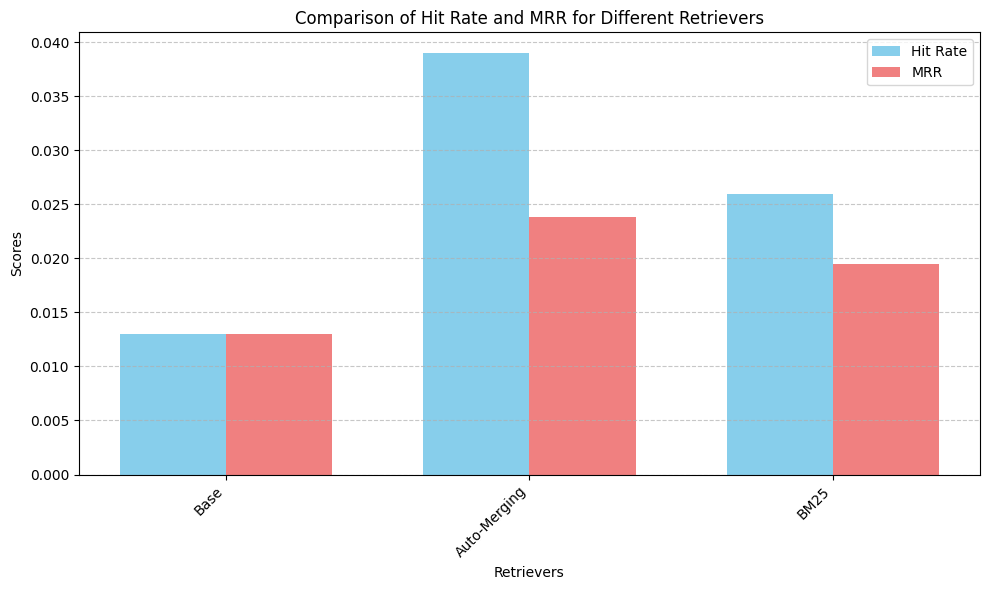

Bar chart comparing Hit Rate and MRR for different retrievers displayed successfully.


In [106]:
bar_width = 0.35
index = np.arange(len(retriever_names))

fig, ax = plt.subplots(figsize=(10, 6))

bar1 = ax.bar(index - bar_width/2, hit_rates, bar_width, label='Hit Rate', color='skyblue')
bar2 = ax.bar(index + bar_width/2, mrr_scores, bar_width, label='MRR', color='lightcoral')

ax.set_xlabel('Retrievers')
ax.set_ylabel('Scores')
ax.set_title('Comparison of Hit Rate and MRR for Different Retrievers')
ax.set_xticks(index)
ax.set_xticklabels(retriever_names, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Bar chart comparing Hit Rate and MRR for different retrievers displayed successfully.")

In [107]:
target_retrievers = ['Base', 'Auto-Merging', 'BM25']

metrics_for_chart = {
    'mrr': [],
    'hit_rate': [],
    'precision': [],
    'recall': []
}

for retriever_name in target_retrievers:
    if retriever_name in mean_metrics_dict:
        metrics_for_chart['mrr'].append(mean_metrics_dict[retriever_name]['mrr'])
        metrics_for_chart['hit_rate'].append(mean_metrics_dict[retriever_name]['hit_rate'])
        metrics_for_chart['precision'].append(mean_metrics_dict[retriever_name]['precision'])
        metrics_for_chart['recall'].append(mean_metrics_dict[retriever_name]['recall'])

print("Extracted Metrics for Chart:")
print(metrics_for_chart)

Extracted Metrics for Chart:
{'mrr': [np.float64(0.012987012987012988), np.float64(0.023809523809523808), np.float64(0.01948051948051948)], 'hit_rate': [np.float64(0.012987012987012988), np.float64(0.03896103896103896), np.float64(0.025974025974025976)], 'precision': [np.float64(0.012987012987012988), np.float64(0.012987012987012988), np.float64(0.012987012987012988)], 'recall': [np.float64(0.012987012987012988), np.float64(0.03896103896103896), np.float64(0.025974025974025976)]}


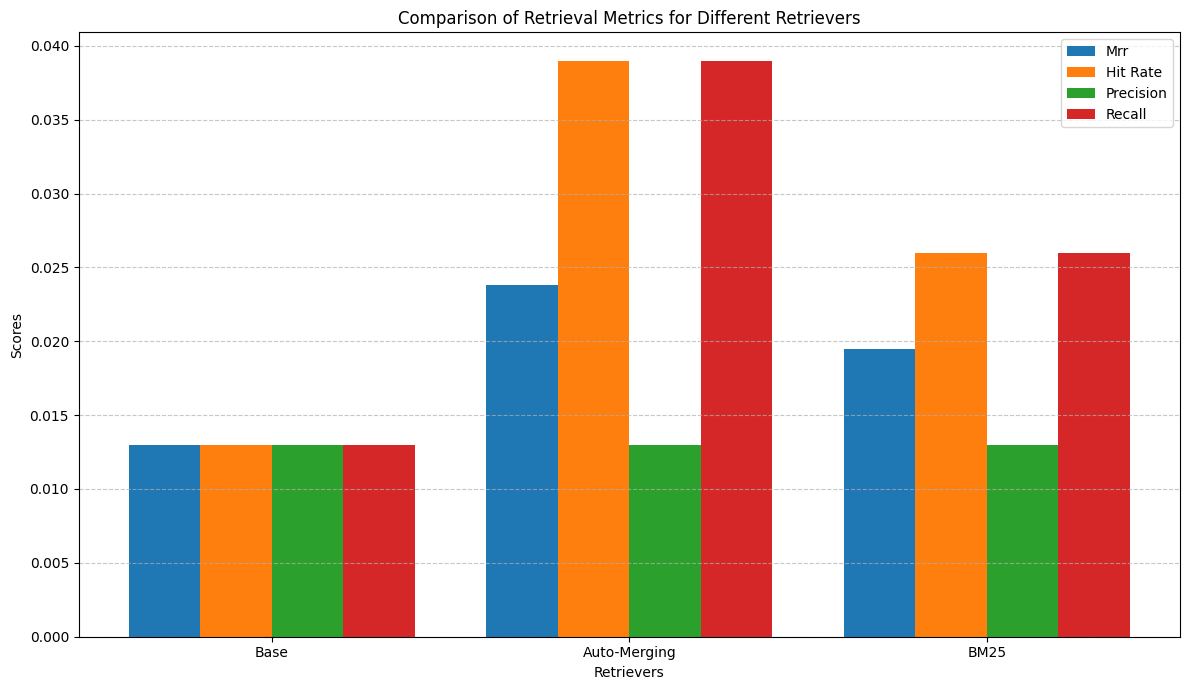

Grouped bar chart displaying MRR, Hit Rate, Precision, and Recall for 'Base', 'Auto-Merging', and 'BM25' retrievers generated successfully.


In [108]:
labels = target_retrievers
metrics = ['mrr', 'hit_rate', 'precision', 'recall']

x = np.arange(len(labels))  # the label locations
width = 0.2  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 7))

# Plotting each metric as a group of bars
for i, metric_name in enumerate(metrics):
    values = metrics_for_chart[metric_name]
    # Adjust position for each group of bars
    rects = ax.bar(x + i*width - (len(metrics)-1)*width/2, values, width, label=metric_name.replace('_', ' ').title())

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Retrievers')
ax.set_ylabel('Scores')
ax.set_title('Comparison of Retrieval Metrics for Different Retrievers')
ax.set_xticks(x) # Set tick locations to the center of each group
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Grouped bar chart displaying MRR, Hit Rate, Precision, and Recall for 'Base', 'Auto-Merging', and 'BM25' retrievers generated successfully.")